# Final Exam 25 - Part 1: GANs and Diffusion

## GANs

In one of your assignments, you were asked to :

1. Develop your own GAN to model data generated (I refer to this as SNAKE dataset) as follows:
   $$\begin{eqnarray} \theta & \sim & {\cal U}(0,2\pi) \\
                      r      & \sim & {\cal N}(0, 1) \\
                      \mathbf{x} & \leftarrow & \begin{cases} \begin{bmatrix} (10+r)\cos\theta \\ (10+r)\sin\theta + 10\end{bmatrix} & \frac{1}{2}\pi \le \theta \le \frac{3}{2}\pi \\ \begin{bmatrix} (10+r)\cos\theta \\ (10+r)\sin\theta - 10\end{bmatrix} & \mathrm{otherwise} \end{cases} \end{eqnarray} $$

For **today's exam** i would like you to do something similar to that but with a little bit of modification

Q1) In stead of the SNAKE dataset, i would like you to generate this data:

$$ \begin{align}
\theta &\sim \mathcal{U}(0, 2\pi) \tag{1} \\
r &\sim \mathcal{N}(0, 0.02^2) \tag{2} \\
\mathbf{x} &\leftarrow 
\begin{cases}
\begin{bmatrix}
16 \sin^3(\theta) (1 + r) \\
\left( 13 \cos(\theta) - 5 \cos(2\theta) - 2 \cos(3\theta) - \cos(4\theta) \right)(1 + r)
\end{bmatrix}
\end{cases}
\tag{3}
\end{align} $$

You should create a PyTorch DataSet that generates the 2D data in the `__init__()` method, outputs a sample in the `__getitem__()` method, and returns the dataset size in the `__len__()` method.

Q2. Use the vanilla GAN approach with an appropriate structure for the generator and discriminator (don't worry i will guide you with the specific architecture


In [1]:
import os
import numpy as np
import errno
import torchvision.utils as vutils
from tensorboardX import SummaryWriter
from IPython import display
from matplotlib import pyplot as plt
import torch

'''
    TensorBoard Data will be stored in './runs' path
'''


class Logger:

    def __init__(self, model_name, data_name):
        self.model_name = model_name
        self.data_name = data_name

        self.comment = '{}_{}'.format(model_name, data_name)
        self.data_subdir = '{}/{}'.format(model_name, data_name)

        # TensorBoard
        self.writer = SummaryWriter(comment=self.comment)

    def log(self, d_error, g_error, epoch, n_batch, num_batches):

        # var_class = torch.autograd.variable.Variable
        if isinstance(d_error, torch.autograd.Variable):
            d_error = d_error.data.cpu().numpy()
        if isinstance(g_error, torch.autograd.Variable):
            g_error = g_error.data.cpu().numpy()

        step = Logger._step(epoch, n_batch, num_batches)
        self.writer.add_scalar(
            '{}/D_error'.format(self.comment), d_error, step)
        self.writer.add_scalar(
            '{}/G_error'.format(self.comment), g_error, step)

    def log_images(self, images, num_images, epoch, n_batch, num_batches, format='NCHW', normalize=True):
        '''
        input images are expected in format (NCHW)
        '''
        if type(images) == np.ndarray:
            images = torch.from_numpy(images)
        
        if format=='NHWC':
            images = images.transpose(1,3)
        

        step = Logger._step(epoch, n_batch, num_batches)
        img_name = '{}/images{}'.format(self.comment, '')

        # Make horizontal grid from image tensor
        horizontal_grid = vutils.make_grid(
            images, normalize=normalize, scale_each=True)
        # Make vertical grid from image tensor
        nrows = int(np.sqrt(num_images))
        grid = vutils.make_grid(
            images, nrow=nrows, normalize=True, scale_each=True)

        # Add horizontal images to tensorboard
        self.writer.add_image(img_name, horizontal_grid, step)

        # Save plots
        self.save_torch_images(horizontal_grid, grid, epoch, n_batch)

    def save_torch_images(self, horizontal_grid, grid, epoch, n_batch, plot_horizontal=True):
        out_dir = './data/images/{}'.format(self.data_subdir)
        Logger._make_dir(out_dir)

        # Plot and save horizontal
        fig = plt.figure(figsize=(16, 16))
        plt.imshow(np.moveaxis(horizontal_grid.numpy(), 0, -1))
        plt.axis('off')
        if plot_horizontal:
            display.display(plt.gcf()) #get current axis
        self._save_images(fig, epoch, n_batch, 'hori')
        plt.close()

        # Save squared
        fig = plt.figure()
        plt.imshow(np.moveaxis(grid.numpy(), 0, -1))
        plt.axis('off')
        self._save_images(fig, epoch, n_batch)
        plt.close()

    def _save_images(self, fig, epoch, n_batch, comment=''):
        out_dir = './data/images/{}'.format(self.data_subdir)
        Logger._make_dir(out_dir)
        fig.savefig('{}/{}_epoch_{}_batch_{}.png'.format(out_dir,
                                                         comment, epoch, n_batch))

    def display_status(self, epoch, num_epochs, n_batch, num_batches, d_error, g_error, d_pred_real, d_pred_fake):
        
        # var_class = torch.autograd.variable.Variable
        if isinstance(d_error, torch.autograd.Variable):
            d_error = d_error.data.cpu().numpy()
        if isinstance(g_error, torch.autograd.Variable):
            g_error = g_error.data.cpu().numpy()
        if isinstance(d_pred_real, torch.autograd.Variable):
            d_pred_real = d_pred_real.data
        if isinstance(d_pred_fake, torch.autograd.Variable):
            d_pred_fake = d_pred_fake.data
        
        
        print('Epoch: [{}/{}], Batch Num: [{}/{}]'.format(
            epoch,num_epochs, n_batch, num_batches)
             )
        print('Discriminator Loss: {:.4f}, Generator Loss: {:.4f}'.format(d_error, g_error))
        print('D(x): {:.4f}, D(G(z)): {:.4f}'.format(d_pred_real.mean(), d_pred_fake.mean()))

    def save_models(self, generator, discriminator, epoch):
        out_dir = './data/models/{}'.format(self.data_subdir)
        Logger._make_dir(out_dir)
        torch.save(generator.state_dict(),
                   '{}/G_epoch_{}'.format(out_dir, epoch))
        torch.save(discriminator.state_dict(),
                   '{}/D_epoch_{}'.format(out_dir, epoch))

    def close(self):
        self.writer.close()

    # Private Functionality

    @staticmethod
    def _step(epoch, n_batch, num_batches):
        return epoch * num_batches + n_batch

    @staticmethod
    def _make_dir(directory):
        try:
            os.makedirs(directory)
        except OSError as e:
            if e.errno != errno.EEXIST:
                raise

#### Q1.1 Dataset class

In [2]:
import numpy as np
import torch

class my_dataset():
    #Your code here
    
    def __init__(self, num_sample=1000):
        self.pi = np.pi
        self.num_sample = num_sample
        self.theta = torch.FloatTensor(self.num_sample, 1).uniform_(0, 2 * self.pi)
        self.r = 0.02 * torch.randn(self.num_sample, 1) 
        self.data = torch.empty(self.num_sample, 2)
        
        for i in range(self.num_sample):
            t = self.theta[i]
            perturb = 1 + self.r[i]  # scaling factor
            x = 16 * torch.sin(t)**3 * perturb
            y = (13 * torch.cos(t) - 5 * torch.cos(2*t) - 2 * torch.cos(3*t) - torch.cos(4*t)) * perturb
            self.data[i, 0] = x
            self.data[i, 1] = y

        self.len = self.data.shape[0]

    def __getitem__(self, index):
        return self.data[index]

    def __len__(self):
        return self.len

In [ ]:
## if you are unable to generate the data please use the following class and carry on with the exam
## However, note that you will be getting points for data generation part

import numpy as np
import torch 
class snake_dataset():
    
    def __init__(self, num_sample = 1000):
        self.pi = np.pi
        self.num_sample = num_sample
        self.r = torch.randn(self.num_sample,1)
        self.theta = torch.FloatTensor(self.num_sample,1).uniform_(0,2*self.pi)
        self.a = 10 + self.r
        self.data = torch.empty(self.num_sample,2)
        #self.label = 0
        # self.Y = torch.empty(self.num_sample,1)
        for i in range(self.num_sample):
            if  0.5* self.pi <= self.theta[i] and self.theta[i] <= (3/2) * self.pi :
                self.a = 10 + self.r[i]
                self.x_data = self.a * torch.cos(self.theta[i])
                self.y_data = (self.a * torch.sin(self.theta[i])) + 10
                self.data[i,0] = self.x_data
                self.data[i,1] = self.y_data

            else:
                self.a = 10 + self.r[i]
                self.x_data = self.a * torch.cos(self.theta[i])
                self.y_data = (self.a * torch.sin(self.theta[i])) - 10
                self.data[i,0] = self.x_data
                self.data[i,1] = self.y_data

        self.len = self.data.shape[0]

    def __getitem__(self, index):
        # return (self.X[index], self.Y[index])
        return self.data[index]

    def __len__(self):
        return self.len

#### Q1.2 Generate dataset

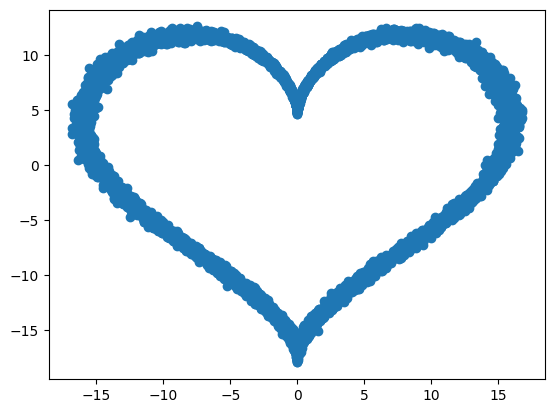

In [3]:
import torch
from torch import nn, optim
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
# Your code: generate your data and show on scatter plot
num_sample = 10000
dataset = my_dataset(num_sample)
plt.scatter(dataset.data[:,0],dataset.data[:,1])

# Your code: prepare your dataloader (bs = 100)
data_loader = torch.utils.data.DataLoader(dataset, batch_size=100, shuffle=True)
num_batches = len(data_loader)

#### Q2 Vanilla GAN

This "vanilla" GAN is the simplest GAN network architecture.

##### Q2.1 For your GeneratorNet

I would like you to create a simple 3-layer neural network. 

It takes a 2-dimensional input, processes it through two hidden layers with LeakyReLU activations, and outputs a 2-dimensional result. Specifically, it consists of two methods

1. **Init method**:

* Layer Definitions:

    - First Hidden Layer (hidden0): A fully connected layer with n_features = 2 inputs and 256 neurons, followed by a LeakyReLU activation with 0.2.

    - Second Hidden Layer (hidden1): Similar to the first hidden layer, this layer takes 256 inputs and outputs 256 neurons, followed by a LeakyReLU activation.

    - Output Layer (out): A fully connected layer that takes the 256 output from the previous layer and transforms it into a size of n_out = 2, followed by a LeakyReLU activation with 0.2.

2. **Forward method**:

The input x passes through the first hidden layer (hidden0), then the second hidden layer (hidden1), and finally the output layer (out), producing the final output.


In [4]:
class GeneratorNet(torch.nn.Module):
    # Your code here
    """
    A three hidden-layer generative neural network
    """
    def __init__(self):
        super(GeneratorNet, self).__init__()
        n_features = 2
        n_out = 2
        
        self.hidden0 = nn.Sequential(
            nn.Linear(n_features, 256),
            nn.LeakyReLU(0.2)
        )
        self.hidden1 = nn.Sequential(            
            nn.Linear(256, 256),
            nn.LeakyReLU(0.2)
        )
        self.out = nn.Sequential(
            nn.Linear(256, n_out),
        )

    def forward(self, x):
        x = self.hidden0(x)
        x = self.hidden1(x)
        x = self.out(x)
        return x

##### Q2.2 DiscriminatorNet

I would like you to create a 3-layer neural network designed for binary classification tasks, specifically in distinguishing real from fake data. 

It takes a 2-dimensional input, processes it through two hidden layers with LeakyReLU activations and dropout regularization, and outputs a scalar value between 0 and 1 indicating the probability of the input being real. Specifically, it consists of two methods

1. **Init method**:

* Layer Definitions:

    - First Hidden Layer (hidden0): A fully connected layer with n_features = 2 inputs and 256 neurons. After the linear transformation, a LeakyReLU activation function with a negative slope of 0.2 is applied, followed by a Dropout layer with a dropout rate of 0.3. Dropout helps prevent overfitting by randomly deactivating neurons during training.

    - Second Hidden Layer (hidden1): Similar to the first hidden layer, this layer has 256 input and output neurons, followed by a LeakyReLU activation and a Dropout with a rate of 0.3.

    - Output Layer (out): A fully connected layer that takes the output of the second hidden layer (size 256) and maps it to a scalar value (n_out = 1). This value is then passed through a Sigmoid activation function to produce a value between 0 and 1, representing the probability of the input being real.

1. **Forward method**:

The input x passes through the first hidden layer (hidden0), then the second hidden layer (hidden1), and finally the output layer (out). The output of the forward pass is a probability, which indicates whether the input is considered real or fake.

In [5]:
class DiscriminatorNet(torch.nn.Module):
    # Your code here
    """
    A three hidden-layer discriminative neural network
    """
    def __init__(self):
        super(DiscriminatorNet, self).__init__()
        n_features = 2
        n_out = 1
        
        self.hidden0 = nn.Sequential( 
            nn.Linear(n_features, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )
        self.hidden1 = nn.Sequential(
            nn.Linear(256, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

        self.out = nn.Sequential(
            torch.nn.Linear(256, n_out),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        #print("discriminator")
        x = self.hidden0(x)
        x = self.hidden1(x)
        x = self.out(x)
        return x
    

Let's create an instance of the generator and discriminator:

In [9]:
#Your code here
discriminator = DiscriminatorNet()
#Your code here
generator = GeneratorNet()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Configured device: ", device)

if torch.cuda.is_available():
    discriminator.to(device)
    generator.to(device)

Configured device:  cuda:0


#### Q2.3 Set up the optimizers and loss function


In [27]:
# Your code here: Optimizers
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Your code here: Loss function
loss = nn.BCELoss()

# Your code here: define your epoch number
num_epochs = 50

# Your code here: define your number of steps to apply to the discriminator for each step of the generator (you can refer to the original paper if you'd like)
d_steps = 1

#### Q2.4 Training

In a GAN (Generative Adversarial Network) setting, the discriminator is trained as a binary classifier — it needs to learn to tell apart real data (from the dataset) and fake data (generated by the generator).

The targets for the discriminator may be 0 or 1 depending on whether we're giving it

##### Q2.4.1 Prepare your target

In [28]:
def real_data_target(size):
    # Your code here
    '''
    Tensor containing ones, with shape = size
    '''
    data = torch.ones(size, 1)
    if torch.cuda.is_available(): return data.cuda(device)
    return data

def fake_data_target(size):
    # Your code here
    '''
    Tensor containing zeros, with shape = size
    '''
    data = torch.zeros(size, 1)
    if torch.cuda.is_available(): return data.cuda(device)
    return data

##### Q2.4.2 Train discriminator:

In [29]:
def train_discriminator(optimizer, real_data, fake_data):
    # Reset gradients
    optimizer.zero_grad()
    
    # Propagate real data
    prediction_real = discriminator(real_data)
    error_real = loss(prediction_real, real_data_target(real_data.size(0)))
    error_real.backward()

    # Propagate fake data
    prediction_fake = discriminator(fake_data)
    error_fake = loss(prediction_fake, fake_data_target(real_data.size(0)))
    error_fake.backward()
    
    # Take a step
    optimizer.step()
    
    # Return error
    return error_real + error_fake, prediction_real, prediction_fake

##### Q2.4.3 Train generator:

In [30]:
def train_generator(optimizer, fake_data):
    # Reset gradients
    optimizer.zero_grad()

    # Propagate the fake data through the discriminator and backpropagate.
    # Note that since we want the generator to output something that gets
    # the discriminator to output a 1, we use the real data target here.
    prediction = discriminator(fake_data)
    error = loss(prediction, real_data_target(prediction.size(0)))
    error.backward()
    
    # Update weights with gradients
    optimizer.step()
    
    # Return error
    return error

##### Q2.4.4 Generate test noise samples:

Let's generate some noise vectors to use as inputs to the generator.
We'll use these samples repeatedly to see the evolution of the generator
over time.

In [31]:
# Function to create noise samples for the generator's input

def noise(size):
    n = torch.randn(size, 2) #[size vector of length 100]
    if torch.cuda.is_available(): return n.cuda(device) 
    return n

num_test_samples = 100
test_noise = noise(num_test_samples)

##### Q2.4.5 Define your training function

Now let's train the model:

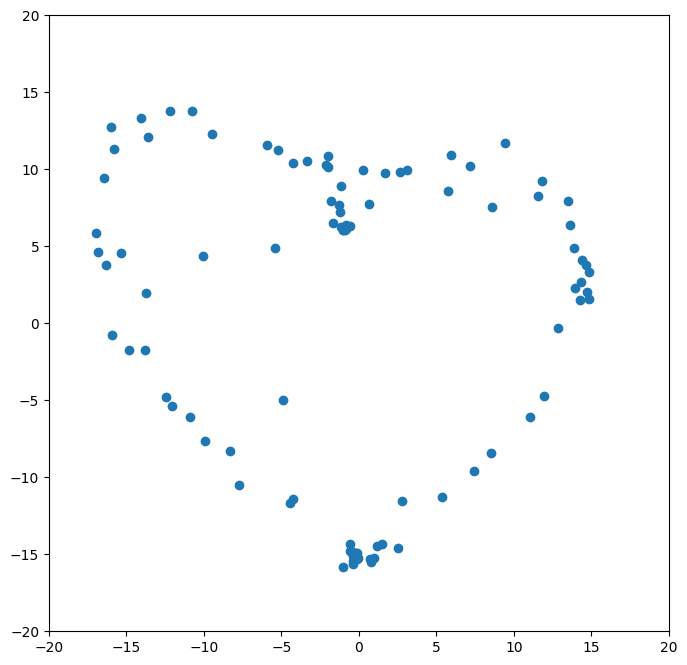

Epoch: [49/50], Batch Num: [90/100]
Discriminator Loss: 1.3747, Generator Loss: 0.7009
D(x): 0.4992, D(G(z)): 0.4926


In [32]:
def plt_output(fake_data):
    plt.figure(figsize=(8,8))
    plt.xlim(-20,20)
    plt.ylim(-20,20)
    plt.scatter(fake_data[:,0], fake_data[:,1])
    plt.show()

logger = Logger(model_name='VGAN', data_name='HEART')

for epoch in range(num_epochs):
    for n_batch, real_batch in enumerate(data_loader):
        # Train discriminator on a real batch and a fake batch
        real_data = real_batch
        real_data = real_data.cuda(device)
        fake_data = generator(noise(real_data.size(0))).detach()
        d_error, d_pred_real, d_pred_fake = train_discriminator(d_optimizer,
                                                                real_data, fake_data)
        
        # Train generator

        fake_data = generator(noise(real_batch.size(0)))
        g_error = train_generator(g_optimizer, fake_data)
        
        # Log errors and display progress

        logger.log(d_error, g_error, epoch, n_batch, num_batches)
        if (n_batch) % 10 == 0:
            display.clear_output(True)
            test_plot = plt_output(generator(test_noise).cpu().detach().numpy())
            # Display status Logs
            logger.display_status(
                epoch, num_epochs, n_batch, num_batches,
                d_error, g_error, d_pred_real, d_pred_fake
            )
            
        # Save model checkpoints
        logger.save_models(generator, discriminator, epoch)

## Diffusion

The idea is quite simple: given an input, we add a little bit of noise step-by-step. With each step, the image becomes less and less clear, until all that is left is noise. This is called the “forward process”. 

Then, we learn a machine learning model that can undo each of such steps, and we call it the “backward process”. 

If we can successfully learn a backward process, we have a model that can generate images from pure random noise.

<img src="img/DDPM.png" title="ResNet18" style="width: 800px;" />

A step in the forward process consists in making the input image noisier (x at step t) by sampling from a multivariate gaussian distribution which mean is a scaled-down version of the previous image (x at step t-1) and which covariance matrix is diagonal and fixed. In other words, we perturb each pixel in the image independently by adding some normally distributed value.

$$\begin{eqnarray}
q(x_t \mid x_{t-1}) := \mathcal{N}\left(x_t; \sqrt{1 - \beta_t} \, x_{t-1}, \beta_t \mathbf{I} \right)
\end{eqnarray}$$

For each step, there is a different coefficient beta that tells how much we are distorting the image in that step. The higher beta is, the more noise is added to the image. We are free to pick coefficients beta, but we should try to not have steps where too much noise is added all at once, and the overall forward process should be “smooth”. In the original work by Ho et. al., betas are put in a linear space from 0.0001 to 0.02.

A nice property of a gaussian distribution is that we can sample from it by adding to the mean vector a normally distributed noise vector scaled by the standard deviation. This results in:

$$\begin{eqnarray}
q(x_t \mid x_{t-1}) = \sqrt{1 - \beta_t} \, x_{t-1} + \sqrt{\beta_t} \, \epsilon
\end{eqnarray}$$

where $$\begin{eqnarray} \epsilon \sim \mathcal{N}(0, \mathbf{I}) \end{eqnarray}$$

We now know how to get the next sample in the forward process by just scaling what we already have and adding some scaled noise. If we now consider that the formula is recursive, we can write:

$$\begin{eqnarray}
q(x_t \mid x_{t-1}) = \sqrt{1 - \beta_t} \, \textcolor{red}{x_{t-1}} + \sqrt{\beta_t} \, \epsilon
\end{eqnarray}$$

$$\begin{eqnarray}
q(x_t \mid x_{t-2}) = \sqrt{1 - \beta_t} \textcolor{red}{\left[\sqrt{1 - \beta_{t-1}} \, x_{t-2} + \sqrt{\beta_{t-1}} \, \epsilon
\right]} + \sqrt{\beta_t} \, \epsilon
\end{eqnarray}$$
$$\begin{eqnarray}
\quad
\underbrace{\phantom{aaaaaaaaaaaaaaaaaaaaa}}_{\textcolor{red}{q(x_{t-1} \mid x_{t-2})}}
\end{eqnarray}$$

If we keep doing this and do some simplifications, we can go all the way back and obtain a formula for getting the noisy sample at step t starting from the original non-noisy image x0:

$$\begin{eqnarray}
\alpha_t := 1 - \beta_t
\end{eqnarray}$$
$$\begin{eqnarray}
\bar{\alpha}_t := \prod_{s=1}^{t} \alpha_s
\end{eqnarray}$$
$$\begin{eqnarray}
q(x_t \mid x_0) = \mathcal{N}\left(x_t; \sqrt{\bar{\alpha}_t} \, x_0, (1 - \bar{\alpha}_t) \mathbf{I}\right)
\end{eqnarray}$$


Therefore, in other words:


$$\begin{eqnarray}
x_t = \sqrt{\bar{\alpha}_t} \, x_0 + \sqrt{1 - \bar{\alpha}_t} \, \epsilon, \quad \epsilon \sim \mathcal{N}(0, \mathbf{I})
\end{eqnarray}$$



Great. Now no matter how many steps our forward process will have, we will always have a way to directly get the noisy image at step t directly from the original image.

So, now your task is

#### Q1) Forward process: Use the data generation function we defined above and prepare the forward process

As mentioned above, βₜ basically controls how much noise you add at each timestep t.

    - A small βₜ → gentle noising (almost the same as previous step).

    - A large βₜ → stronger noising (big jump toward pure noise).

So how do we choose the appropriate beta function?

There’s no absolute "one true" way — but some common practices are:

1. Linear scheduler - refer to [the DDPM paper](https://arxiv.org/abs/2006.11239)
2. Quadratic - refer to [the Improved DDPM paper](https://arxiv.org/abs/2102.09672)

For this exam please use the Linear scheduler

In [33]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [34]:
# Create dataset
dataset = my_dataset(num_sample=1000)
X = dataset.data  # shape (1000, 2)

##### Q1.1) Prepare your q function

In [35]:
# Define diffusion process
T = 1000 
# Your code here: define your beta (noise scheduler)
beta = torch.linspace(1e-4, 0.02, T)
# Your code here: define your alpha 
alpha = 1. - beta
# Your code here: define your alpha bar (Hint: please use torch.cuprod, refer the booklet i prepared for you)
alpha_bar = torch.cumprod(alpha, dim=0)


# Your code here: define your q function
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ab = torch.sqrt(alpha_bar[t])[:, None]
    sqrt_one_minus_ab = torch.sqrt(1 - alpha_bar[t])[:, None]
    return sqrt_ab * X + sqrt_one_minus_ab * noise


##### Q1.2) Visualize noising at different timesteps [0,50,200,500,999]

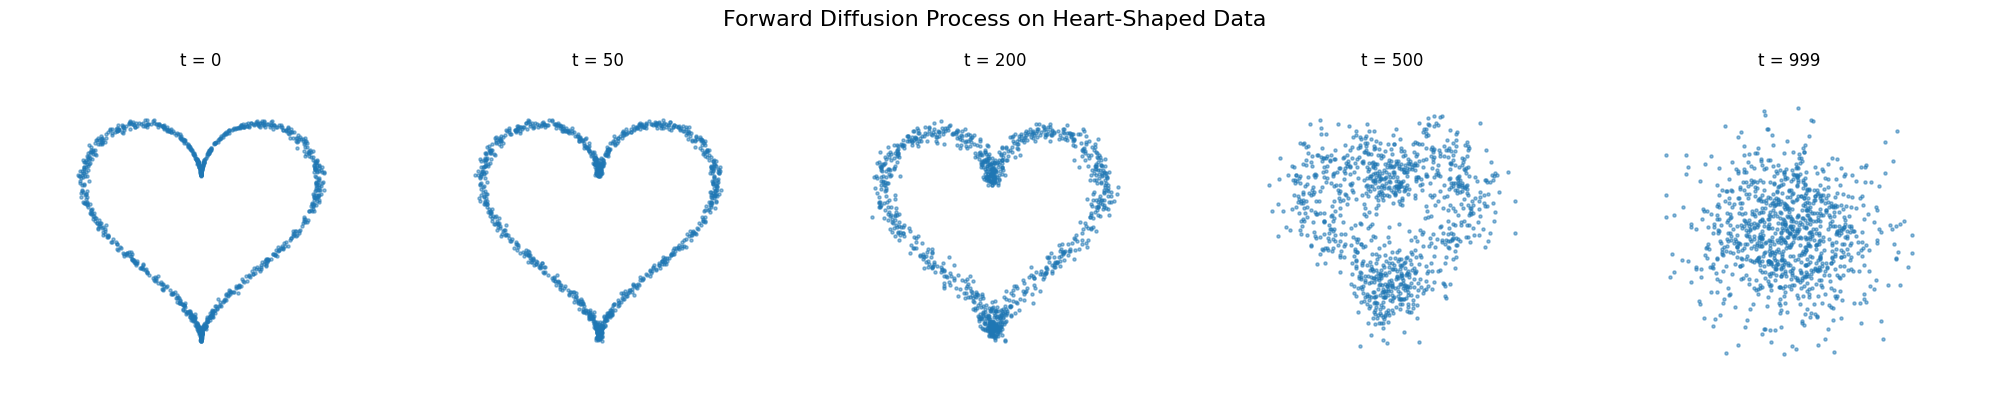

In [36]:
# Visualize noising at different timesteps
timesteps = [0, 50, 200, 500, 999]
noised_data = []

for t in timesteps:
    t_batch = torch.full((X.size(0),), t, dtype=torch.long)
    xt = q_sample(X, t_batch)
    noised_data.append(xt.numpy())

# Plot
fig, axes = plt.subplots(1, len(timesteps), figsize=(20, 4))
for ax, xt, t in zip(axes, noised_data, timesteps):
    ax.scatter(xt[:, 0], xt[:, 1], alpha=0.5, s=5)
    ax.set_title(f"t = {t}")
    ax.axis('equal')
    ax.axis('off')

plt.suptitle("Forward Diffusion Process on Heart-Shaped Data", fontsize=16)
plt.tight_layout()
plt.show()

This is what mine looks like incase you need example

<img src="img/noising_example.png" title="ResNet18" style="width: 800px;" />

##### Q2) Backward process 

For the backward process, we know our model should also work as a gaussian distribution, so we would just need the model to predict the distribution mean and standard deviation given the noisy image and time step. 

In practice, in this first paper on DDPMs the covariance matrix is kept fixed, so we only really want to predict the mean of the gaussian (given the noisy image and the time step we are at currently)

Since it is predicting mean guassian at the given time step,  The model utilizes a neural network that takes both a noisy image $x_{t-1}$ at timestep $t$ and the timestep $t$  itself as inputs. This approach allows the network to learn the conditional distribution $p_\theta(x_{t-1} \mid x_t, t)$ , enabling it to progressively reconstruct the original image from its noisy version.

To effectively incorporate the timestep information, a time embedding technique is employed. This involves projecting the timestep $t$  into a higher-dimensional space using a sinusoidal encoding

The resulting embedding is then added to the feature maps within the neural network. This method allows the network to distinguish between different stages of the diffusion process, enhancing its ability to remove noise at each step

Now, let's define our noise predicting model

In [37]:
# Here i have prepared you the time bedding model
def sinusoidal_embedding(timesteps, dim):
    device = timesteps.device
    half_dim = dim // 2
    emb = np.log(10000) / (half_dim - 1)
    emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
    emb = timesteps[:, None] * emb[None, :]
    emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=1)
    return emb

##### Q2.1) Define the model 

Since our data is simple, we don't need a big neural network.

I would like you to create a lightweight two-layer fully connected neural network designed for regression tasks, specifically for predicting a 2-dimensional noise vector from noisy 2D inputs conditioned on the diffusion timestep. It incorporates a sinusoidal positional embedding of the timestep to enrich the model's awareness of the diffusion stage.

This model is optimized for simple, low-dimensional tasks, such as toy datasets in 2D denoising diffusion models (DDPM). It consists of two main methods:

1. Init method:
* Layer Architecture:
    - Timestep Embedding: The scalar timestep $t$ is passed through a sinusoidal embedding function `sinusoidal_embedding` to produce a high-dimensional representation of size `time_embed_dim}` (default: 32 dimensions). This transforms the scalar timestep into a richer, continuous representation, which better informs the network about the position within the diffusion process.
    - Input Layer: A fully connected (linear) layer that accepts a concatenated input of 2 noisy coordinates ($x$ , $y$ ) and the embedded timestep (total input size = 2 + 32 = 34 features). This layer projects the input into a 128-dimensional hidden space, followed by a ReLU activation function to introduce non-linearity.
    - Output Layer: A fully connected (linear) layer that maps the 128-dimensional hidden representation directly into a 2-dimensional output, corresponding to the predicted noise vector ( $\epsilon_{x}$ , $\epsilon_{y}$ ).

2. Forward pass:
The model receives:
    - A batch of noisy 2D points $x \in \mathbb{R}^2$
    - A batch of corresponding scalar timesteps $t$.
   
   The timestep $t$ is first processed through the `sinusoidal_embedding` function to produce a vector of dimension `time_embed_dim`. The noisy input $x$ and the embedded timestep $t_{emb}$ are then concatenated along the feature dimension to form a unified input vector for each sample. This combined input is passed sequentially through the input layer (with ReLU activation) and the output layer to produce the final predicted noise vector. The model outputs a 2-dimensional vector representing the estimated noise that was added to the original clean sample at timestep $t$.

In [38]:
class BackwardProcess(nn.Module):
    # Your code here
    def __init__(self, time_embed_dim=32):
        super().__init__()
        self.time_embed_dim = time_embed_dim
        self.net = nn.Sequential(
            nn.Linear(2 + time_embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x, t):
        t_emb = sinusoidal_embedding(t, self.time_embed_dim)
        x_input = torch.cat([x, t_emb], dim=1)
        return self.net(x_input)

Define your model, optimizer and loss function 

In [39]:
model = BackwardProcess()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

##### Q2.2) Train your model

In [40]:
# Define your training
for epoch in range(1000):
    t = torch.randint(0, T, (X.shape[0],))
    noise = torch.randn_like(X)
    x_t = q_sample(X, t, noise)
    noise_pred = model(x_t, t)
    loss = loss_fn(noise_pred, noise)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: loss = {loss.item():.4f}")


Epoch 0: loss = 1.1627
Epoch 100: loss = 0.8155
Epoch 200: loss = 0.6246
Epoch 300: loss = 0.6147
Epoch 400: loss = 0.5844
Epoch 500: loss = 0.5965
Epoch 600: loss = 0.5284
Epoch 700: loss = 0.5518
Epoch 800: loss = 0.5211
Epoch 900: loss = 0.5770


##### Q2.3) Lets use our model

After training the DDPM model to predict the noise added at each diffusion step, we now move on to the **sampling phase** — that is, **generating new data** starting from pure noise.

Let's create a sampling functions `p_sample(x, t)`:

This function performs **one reverse diffusion step**.  
Given a noisy sample $x_{t}$ at timestep $t$, it produces a slightly denoised sample $x_{t-1}$.

This function should:
1. Predict noise:
    - The trained model predicts the noise $\epsilon_{\theta(x_{t-1},t)}$ that was added to $x_{t}$.
3. Compute the mean:  
    - Based on the predicted noise, we compute the mean $\mu_\theta(x_t, t)$of the reverse distribution $p_\theta(x_{t-1} \mid x_t)$.
4. Add randomness:  
    <!-- - We add small Gaussian noise scaled by $\sqrt{\beta_t}$ to the mean.  This ensures diversity in the generated samples. -->
    - We add Gaussian noise $z \sim \mathcal{N}(0, I)$scaled by $\sqrt{\beta_t}$ to the mean.
    - This introduces stochasticity and ensures diversity in generated samples.
5. Special case when $t=0$:  
    - When $t=0$, no noise is added because the sample should be fully denoised.

### In formula:
$$\begin{equation}
x_{t-1} = \text{mean}(x_t) + \sqrt{\beta_t} \times z
\end{equation}$$

where $z$ is random noise if $t > 0$, or zero if $t=0$ and

$$\begin{equation}
\mu_\theta(x_t, t) = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(x_t, t) \right)
\end{equation}$$


In [41]:
@torch.no_grad()
def p_sample(x, t):
    # Your code here
    beta_t = beta[t]
    sqrt_one_minus_ab = torch.sqrt(1 - alpha_bar[t])
    mean = (1 / torch.sqrt(alpha[t])) * (x - beta_t / sqrt_one_minus_ab * model(x, torch.tensor([t]*x.shape[0])))
    if t > 0:
        z = torch.randn_like(x)
    else:
        z = torch.zeros_like(x)
    return mean + torch.sqrt(beta_t) * z


##### Q2.4) Generate and visualize your data

Generate and visualize new samples from a trained Denoising Diffusion Probabilistic Model (DDPM) by reversing the noise process step-by-step — turning random noise back into structured data.

Hint:
- Start from the pure noise
- Apply the leared reverse denoising steps $t = T$ -> $0$
- Apply the Reverse Diffusion Process (your `p_sample(x,t)`) to progressively removes noise, making the samples more structured step-by-step.


In [42]:
@torch.no_grad()
def sample_ddpm():
    # Your code here
    x = torch.randn(1000, 2)
    for t_ in reversed(range(T)):
        x = p_sample(x, t_)
    return x

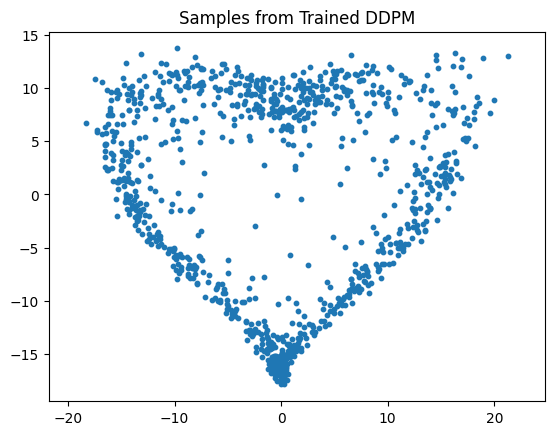

In [43]:
samples = sample_ddpm()
plt.scatter(samples[:, 0], samples[:, 1], s=10)
plt.title("Samples from Trained DDPM")
plt.axis("equal")
plt.show()

#### Q3) Dicussion


In this exercise, you trained two different types of generative models — GANs and Diffusion Models — on a simple 2D dataset.

While both models aim to generate samples similar to the training data, they approach the problem very differently.

    - GANs learn a direct mapping from random noise to data by setting up a competition between a generator and a discriminator.

    - Diffusion models, on the other hand, start with pure noise and gradually denoise it step-by-step based on learned dynamics.

Even though the dataset was simple, some key differences in training behavior may be observed e.g. training stability, sample quality, and sampling speed between the two models.

1) Reflecting on your experience accordingly
2) Suppose you scale up to a much more complex, high-dimensional dataset, reflect and discuss
    - Would you choose a GAN or a Diffusion Model?
    - Which trade-offs (speed, stability, quality) would matter most in your choice, and why?